In [1]:
import os, time, json, warnings
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
warnings.filterwarnings('ignore', message='Was asked to gather along dimension 0')

DATA_DIR = '/kaggle/input/datasets/pavithra1mj/roberta-model'
OUT_DIR = '/kaggle/working'
MODEL = 'roberta-base'
EPOCHS = 10
SEED = 42

In [2]:
exts = ('.csv', '.tsv', '.txt', '.xlsx', '.xls', '.json', '.jsonl', '.parquet')
root = DATA_DIR if os.path.exists(DATA_DIR) else '/kaggle/input'
cands = [os.path.join(r, f) for r, _, fs in os.walk(root) for f in fs if f.lower().endswith(exts)]
if os.path.isfile(DATA_DIR): cands = [DATA_DIR]
assert cands, os.listdir('/kaggle/input')
for c in cands: print(c, os.path.getsize(c))

/kaggle/input/datasets/pavithra1mj/roberta-model/labeled_bert_dataset by perplexity.json 857038


In [3]:
def load(path):
    e = os.path.splitext(path)[1].lower()
    if e == '.csv': return pd.read_csv(path)
    if e in ('.tsv', '.txt'): return pd.read_csv(path, sep='\t')
    if e in ('.xlsx', '.xls'): return pd.read_excel(path)
    if e == '.jsonl': return pd.read_json(path, lines=True)
    if e == '.json':
        with open(path) as f: raw = json.load(f)
        if isinstance(raw, dict): raw = next(v for v in raw.values() if isinstance(v, list))
        return pd.DataFrame(raw)
    return pd.read_parquet(path)

fp = cands[0]
df = load(fp)
print(fp, df.shape)
print(df.dtypes)
print(df.head())

/kaggle/input/datasets/pavithra1mj/roberta-model/labeled_bert_dataset by perplexity.json (7953, 2)
text     object
label    object
dtype: object
                                                text   label
0           Compare Donald Trump and Vladimir Putin.  NORMAL
1               They are both political narcissists.  NORMAL
2             Putin is more of an outright dictator.  NORMAL
3                    Donald Trump is not a dictator.  NORMAL
4  Every lawsuit that was against him, he still a...  NORMAL


In [5]:
cols = df.columns.tolist()
TEXT_COL = next((c for c in cols if c.lower() in ('text', 'sentence', 'transcript', 'content')), None)
LABEL_COL = next((c for c in cols if c.lower() in ('label', 'labels', 'class', 'category', 'target')), None)
if TEXT_COL is None:
    TEXT_COL = max([c for c in cols if c != LABEL_COL and df[c].dtype == object], key=lambda c: df[c].astype(str).str.len().mean())
if LABEL_COL is None:
    LABEL_COL = min([c for c in cols if c != TEXT_COL], key=lambda c: df[c].nunique())
print(TEXT_COL, LABEL_COL)

df = df[[TEXT_COL, LABEL_COL]].dropna().drop_duplicates(TEXT_COL).reset_index(drop=True)
le = LabelEncoder()
df['label'] = le.fit_transform(df[LABEL_COL].astype(str))
names = [str(x) for x in le.classes_]
NUM = len(names)
ID2LABEL = {i: n for i, n in enumerate(names)}
LABEL2ID = {n: i for i, n in ID2LABEL.items()}
print(df['label'].map(ID2LABEL).value_counts())

text label
label
2    4916
1    1936
3     189
0     189
Name: count, dtype: int64


In [6]:
strat = df['label'] if df['label'].value_counts().min() >= 10 else None
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=strat)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'] if strat is not None else None)
print(len(train_df), len(val_df), len(test_df))

5784 723 723


In [7]:
tok = AutoTokenizer.from_pretrained(MODEL)

class DS(torch.utils.data.Dataset):
    def __init__(self, d):
        self.enc = tok(d[TEXT_COL].astype(str).tolist(), truncation=True, max_length=128)
        self.y = d['label'].astype(int).tolist()
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = self.y[i]
        return item

train_ds, val_ds, test_ds = DS(train_df), DS(val_df), DS(test_df)
collator = DataCollatorWithPadding(tok)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [8]:
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    pw, rw, fw, _ = precision_recall_fscore_support(p.label_ids, preds, average='weighted', zero_division=0)
    pm, rm, fm, _ = precision_recall_fscore_support(p.label_ids, preds, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(p.label_ids, preds), 'precision_weighted': pw, 'recall_weighted': rw, 'f1_weighted': fw,
            'precision_macro': pm, 'recall_macro': rm, 'f1_macro': fm}

model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM, id2label=ID2LABEL, label2id=LABEL2ID)

n_gpu = max(1, torch.cuda.device_count())
warmup = int(0.1 * -(-len(train_ds) // (16 * n_gpu)) * EPOCHS)

args = TrainingArguments(
    output_dir=f'{OUT_DIR}/roberta_out',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup,
    eval_strategy='epoch',
    save_strategy='no',
    logging_strategy='epoch',
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none'
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                  data_collator=collator, compute_metrics=compute_metrics)

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
t0 = time.time()
trainer.train()
train_time = time.time() - t0
print(train_time)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,Precision Macro,Recall Macro,F1 Macro
1,1.555718,0.465949,0.928077,0.881429,0.928077,0.903748,0.452750,0.486589,0.468792
2,0.386022,0.265615,0.957123,0.961969,0.957123,0.959019,0.797898,0.863315,0.826017
3,0.219665,0.309599,0.961272,0.961057,0.961272,0.960663,0.845635,0.816602,0.826724
4,0.149842,0.329533,0.959889,0.964713,0.959889,0.961572,0.803039,0.874620,0.833155
5,0.085652,0.385450,0.962656,0.970540,0.962656,0.965223,0.807631,0.927022,0.855527
6,0.067629,0.369021,0.966805,0.971890,0.966805,0.968309,0.833482,0.928547,0.872224
7,0.040556,0.393093,0.959889,0.968179,0.959889,0.962595,0.799118,0.911782,0.843815
8,0.025226,0.451648,0.962656,0.967294,0.962656,0.964324,0.814577,0.888286,0.846243
9,0.012248,0.462684,0.964039,0.971587,0.964039,0.966327,0.818760,0.938606,0.866604
10,0.014855,0.446844,0.962656,0.967294,0.962656,0.964324,0.814577,0.888286,0.846243


476.0994849205017


              precision    recall  f1-score   support

           0       0.67      0.74      0.70        19
           1       0.95      0.96      0.96       194
           2       0.99      0.98      0.98       491
           3       0.75      0.63      0.69        19

    accuracy                           0.96       723
   macro avg       0.84      0.83      0.83       723
weighted avg       0.96      0.96      0.96       723



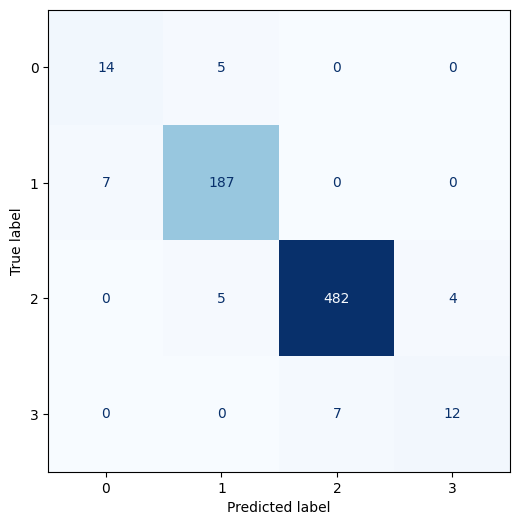

In [10]:
t1 = time.time()
pred = trainer.predict(test_ds)
eval_time = time.time() - t1

y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)
print(classification_report(y_true, y_pred, labels=range(NUM), target_names=names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=range(NUM))
pd.DataFrame(cm, index=names, columns=names).to_csv(f'{OUT_DIR}/confusion_matrix.csv')
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm, display_labels=names).plot(ax=ax, cmap='Blues', colorbar=False)
plt.savefig(f'{OUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
pw, rw, fw, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
pm, rm, fm, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

summary = {
    'model': MODEL, 'epochs': EPOCHS, 'batch_size': 16, 'learning_rate': 2e-5,
    'train_samples': len(train_ds), 'val_samples': len(val_ds), 'test_samples': len(test_ds),
    'accuracy': accuracy_score(y_true, y_pred),
    'precision_weighted': pw, 'recall_weighted': rw, 'f1_weighted': fw,
    'precision_macro': pm, 'recall_macro': rm, 'f1_macro': fm,
    'train_wall_time_sec': round(train_time, 2), 'eval_wall_time_sec': round(eval_time, 2),
    'total_wall_time_sec': round(train_time + eval_time, 2)
}
pd.DataFrame([summary]).to_csv(f'{OUT_DIR}/evaluation_metrics.csv', index=False)

p_c, r_c, f_c, s_c = precision_recall_fscore_support(y_true, y_pred, labels=range(NUM), zero_division=0)
pd.DataFrame({'class': names, 'precision': p_c, 'recall': r_c, 'f1': f_c, 'support': s_c}).to_csv(f'{OUT_DIR}/per_class_metrics.csv', index=False)
pd.DataFrame(trainer.state.log_history).to_csv(f'{OUT_DIR}/training_log.csv', index=False)
print(pd.read_csv(f'{OUT_DIR}/evaluation_metrics.csv').T)

                                0
model                roberta-base
epochs                         10
batch_size                     16
learning_rate             0.00002
train_samples                5784
val_samples                   723
test_samples                  723
accuracy                 0.961272
precision_weighted       0.961328
recall_weighted          0.961272
f1_weighted              0.961103
precision_macro          0.837898
recall_macro             0.828502
f1_macro                 0.831477
train_wall_time_sec         476.1
eval_wall_time_sec           1.65
total_wall_time_sec        477.75


In [12]:
trainer.save_model(f'{OUT_DIR}/roberta_finetuned')
tok.save_pretrained(f'{OUT_DIR}/roberta_finetuned')
pd.DataFrame({'label': names, 'id': range(NUM)}).to_csv(f'{OUT_DIR}/label_map.csv', index=False)
print(os.listdir(OUT_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['per_class_metrics.csv', '.virtual_documents', 'label_map.csv', 'evaluation_metrics.csv', 'confusion_matrix.csv', 'training_log.csv', 'roberta_finetuned', 'confusion_matrix.png', 'roberta_out']


In [13]:
import base64
from IPython.display import HTML, display
for f in ['evaluation_metrics.csv', 'per_class_metrics.csv', 'confusion_matrix.csv', 'training_log.csv', 'confusion_matrix.png']:
    b = base64.b64encode(open(f'{OUT_DIR}/{f}', 'rb').read()).decode()
    display(HTML(f'<a download="{f}" href="data:application/octet-stream;base64,{b}">Download {f}</a>'))